In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
import os

csv_scores    = '../results/sentiment_analysis/yelp_academic_dataset_review_scored.csv'
csv_business  = '../data/csv/yelp_academic_dataset_business.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [ ]:
df_scores = pl.scan_csv(csv_scores, ignore_errors=True)

print('Columnas disponibles en el CSV de scores:')
print(df_scores.collect_schema().names())

Columnas disponibles en el CSV de scores:
['review_id', 'user_id', 'business_id', 'stars', 'text', 'date', 'num_chars', 'vader_score', 'afinn_score', 'nrc_anger', 'nrc_anticipation', 'nrc_disgust', 'nrc_fear', 'nrc_joy', 'nrc_negative', 'nrc_positive', 'nrc_sadness', 'nrc_surprise', 'nrc_trust', 'nrc_compound']


In [ ]:
# La tendencia temporal se aproxima mediante la diferencia entre el sentimiento
# medio de la primera mitad de reseñas y la segunda mitad, ordenadas por fecha.

df_agg = (
    df_scores
    .sort('date')
    .with_columns(
        pl.col('text')
        .str.split(' ')
        .list.len()
        .alias('word_count')
    )
    .group_by('business_id')
    .agg([
        pl.len().alias('review_count_scores'),
        pl.col('vader_score').mean().alias('vader_mean'),
        pl.col('afinn_score').mean().alias('afinn_mean'),
        pl.col('word_count').mean().alias('word_count_mean'),
        pl.col('stars').var().alias('stars_variance'),
        pl.col('stars').mean().alias('stars_review_mean'),
        pl.col('vader_score').tail(
            (pl.len() / 2).cast(pl.Int32)
        ).mean().alias('vader_recent_mean'),
        pl.col('vader_score').head(
            (pl.len() / 2).cast(pl.Int32)
        ).mean().alias('vader_early_mean'),
    ])
    .with_columns(
        (pl.col('vader_recent_mean') - pl.col('vader_early_mean')).alias('vader_trend')
    )
    .drop(['vader_recent_mean', 'vader_early_mean'])
)

print('Agregación completada. Shape:')
print(df_agg.collect().shape)

Agregación completada. Shape:
(150346, 8)


In [ ]:
df_business = pl.scan_csv(csv_business, ignore_errors=True).select([
    'business_id',
    'stars',
    'review_count',
    'is_open',
    'categories',
    'city',
    'state',
])

df_model = (
    df_agg
    .join(df_business, on='business_id', how='inner')
    .collect()
)

print(f'Dataset final: {df_model.shape[0]:,} negocios x {df_model.shape[1]} columnas')
print(df_model.head(3))

Dataset final: 150,243 negocios x 14 columnas
shape: (3, 14)
┌────────────┬────────────┬────────────┬────────────┬───┬─────────┬────────────┬───────────┬───────┐
│ business_i ┆ review_cou ┆ vader_mean ┆ afinn_mean ┆ … ┆ is_open ┆ categories ┆ city      ┆ state │
│ d          ┆ nt_scores  ┆ ---        ┆ ---        ┆   ┆ ---     ┆ ---        ┆ ---       ┆ ---   │
│ ---        ┆ ---        ┆ f64        ┆ f64        ┆   ┆ i64     ┆ str        ┆ str       ┆ str   │
│ str        ┆ u32        ┆            ┆            ┆   ┆         ┆            ┆           ┆       │
╞════════════╪════════════╪════════════╪════════════╪═══╪═════════╪════════════╪═══════════╪═══════╡
│ Bmh7d4yVxp ┆ 38         ┆ 4.012363   ┆ 3.989845   ┆ … ┆ 1       ┆ Restaurant ┆ Philadelp ┆ PA    │
│ gLPQ8KLcy_ ┆            ┆            ┆            ┆   ┆         ┆ s,         ┆ hia       ┆       │
│ 4Q         ┆            ┆            ┆            ┆   ┆         ┆ American   ┆           ┆       │
│            ┆            ┆   

In [ ]:
print('Valores nulos por columna:')
print(df_model.null_count())

Valores nulos por columna:
shape: (1, 14)
┌─────────────┬────────────────┬────────────┬────────────┬───┬─────────┬────────────┬──────┬───────┐
│ business_id ┆ review_count_s ┆ vader_mean ┆ afinn_mean ┆ … ┆ is_open ┆ categories ┆ city ┆ state │
│ ---         ┆ cores          ┆ ---        ┆ ---        ┆   ┆ ---     ┆ ---        ┆ ---  ┆ ---   │
│ u32         ┆ ---            ┆ u32        ┆ u32        ┆   ┆ u32     ┆ u32        ┆ u32  ┆ u32   │
│             ┆ u32            ┆            ┆            ┆   ┆         ┆            ┆      ┆       │
╞═════════════╪════════════════╪════════════╪════════════╪═══╪═════════╪════════════╪══════╪═══════╡
│ 0           ┆ 0              ┆ 0          ┆ 0          ┆ … ┆ 0       ┆ 0          ┆ 0    ┆ 0     │
└─────────────┴────────────────┴────────────┴────────────┴───┴─────────┴────────────┴──────┴───────┘


Distribución de is_open:
  Cerrado (0): 30,640 (20.4%)
  Abierto (1): 119,603 (79.6%)


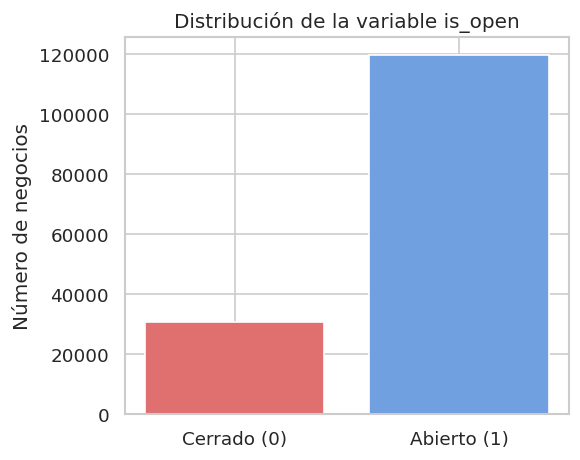

In [ ]:
counts = df_model['is_open'].value_counts().sort('is_open')
total  = df_model.shape[0]

print('Distribución de is_open:')
for row in counts.iter_rows(named=True):
    label = 'Abierto' if row['is_open'] == 1 else 'Cerrado'
    print(f'  {label} ({row["is_open"]}): {row["count"]:,} ({row["count"] / total * 100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Cerrado (0)', 'Abierto (1)'],
       counts['count'].to_list(),
       color=['#e07070', '#70a0e0'])
ax.set_title('Distribución de la variable is_open')
ax.set_ylabel('Número de negocios')
plt.tight_layout()
plt.show()

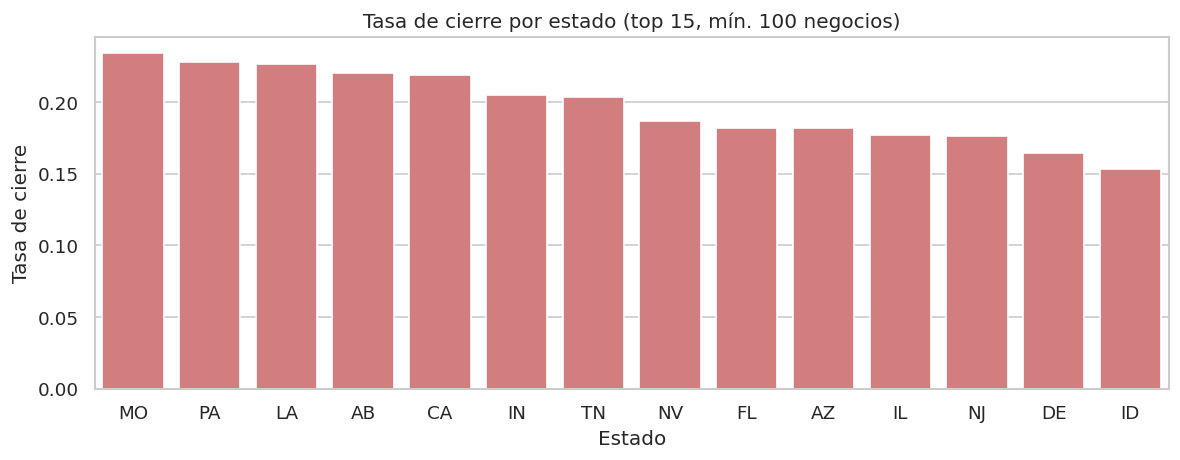

In [ ]:
cierre_estado = (
    df_model
    .group_by('state')
    .agg([
        pl.len().alias('total'),
        (pl.col('is_open') == 0).sum().alias('cerrados'),
    ])
    .with_columns(
        (pl.col('cerrados') / pl.col('total')).alias('tasa_cierre')
    )
    .filter(pl.col('total') >= 100)
    .sort('tasa_cierre', descending=True)
    .head(15)
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=cierre_estado, x='state', y='tasa_cierre', ax=ax, color='#e07070')
ax.set_title('Tasa de cierre por estado (top 15, mín. 100 negocios)')
ax.set_ylabel('Tasa de cierre')
ax.set_xlabel('Estado')
plt.tight_layout()
plt.show()

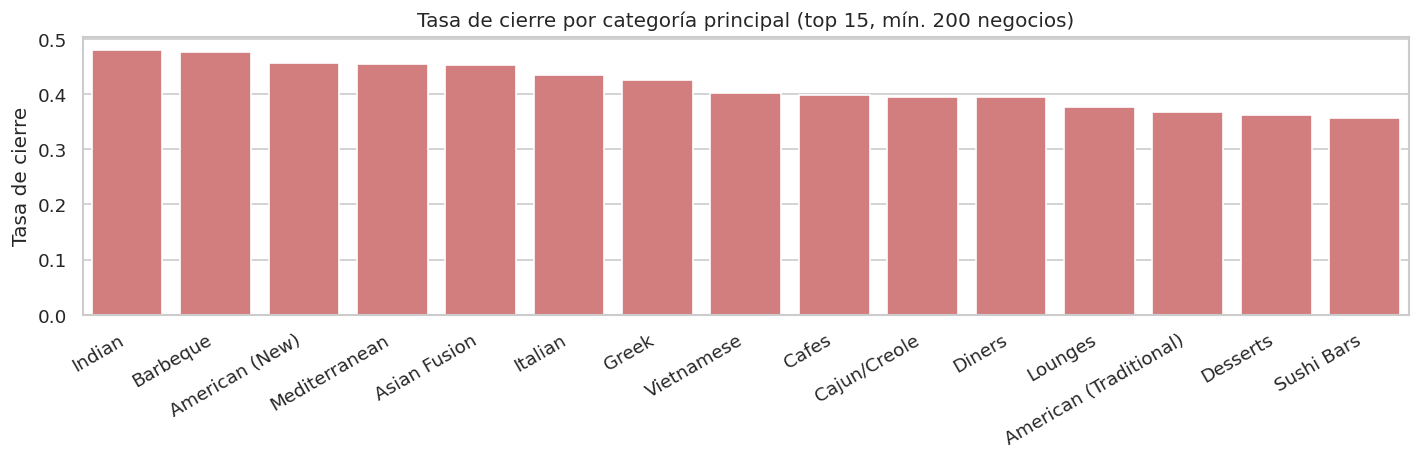

In [ ]:
# Extraemos la primera categoría listada como categoría principal del negocio
cierre_cat = (
    df_model
    .with_columns(
        pl.col('categories')
        .str.split(', ')
        .list.first()
        .alias('main_category')
    )
    .group_by('main_category')
    .agg([
        pl.len().alias('total'),
        (pl.col('is_open') == 0).sum().alias('cerrados'),
    ])
    .with_columns(
        (pl.col('cerrados') / pl.col('total')).alias('tasa_cierre')
    )
    .filter(pl.col('total') >= 200)
    .sort('tasa_cierre', descending=True)
    .head(15)
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=cierre_cat, x='main_category', y='tasa_cierre', ax=ax, color='#e07070')
ax.set_title('Tasa de cierre por categoría principal (top 15, mín. 200 negocios)')
ax.set_ylabel('Tasa de cierre')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19569/2119366910.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19569/2119366910.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


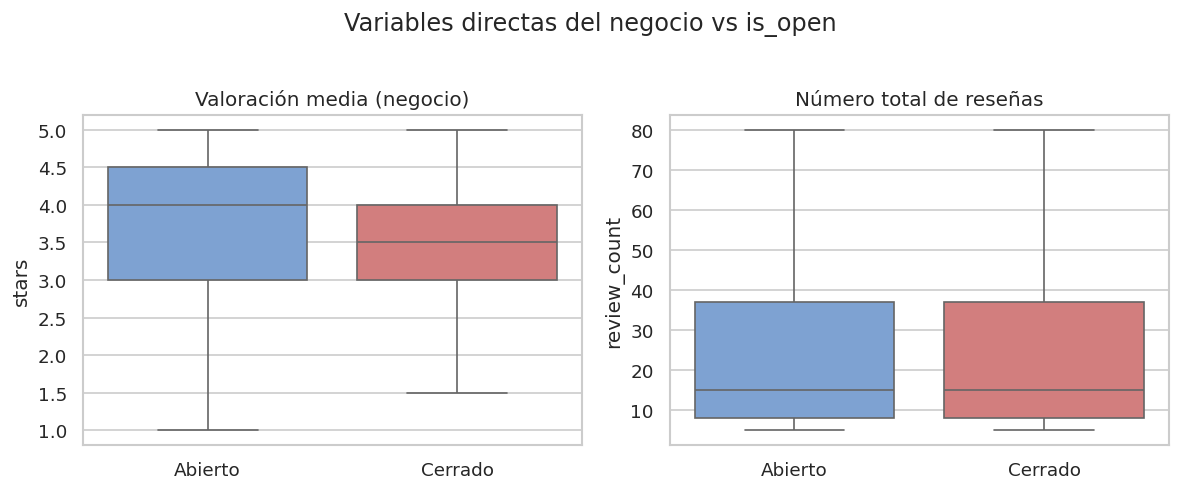

In [ ]:
df_pd = df_model.to_pandas()
df_pd['is_open_label'] = df_pd['is_open'].map({1: 'Abierto', 0: 'Cerrado'})

features_negocio = {
    'stars':        'Valoración media (negocio)',
    'review_count': 'Número total de reseñas',
}

fig, axes = plt.subplots(1, len(features_negocio), figsize=(10, 4))

for ax, (col, title) in zip(axes, features_negocio.items()):
    sns.boxplot(
        data=df_pd,
        x='is_open_label',
        y=col,
        ax=ax,
        palette={'Abierto': '#70a0e0', 'Cerrado': '#e07070'},
        showfliers=False
    )
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Variables directas del negocio vs is_open', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19569/163280144.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19569/163280144.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19569/163280144.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19569/163280144.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19569/163280144.py:13: FutureWarning: 

P

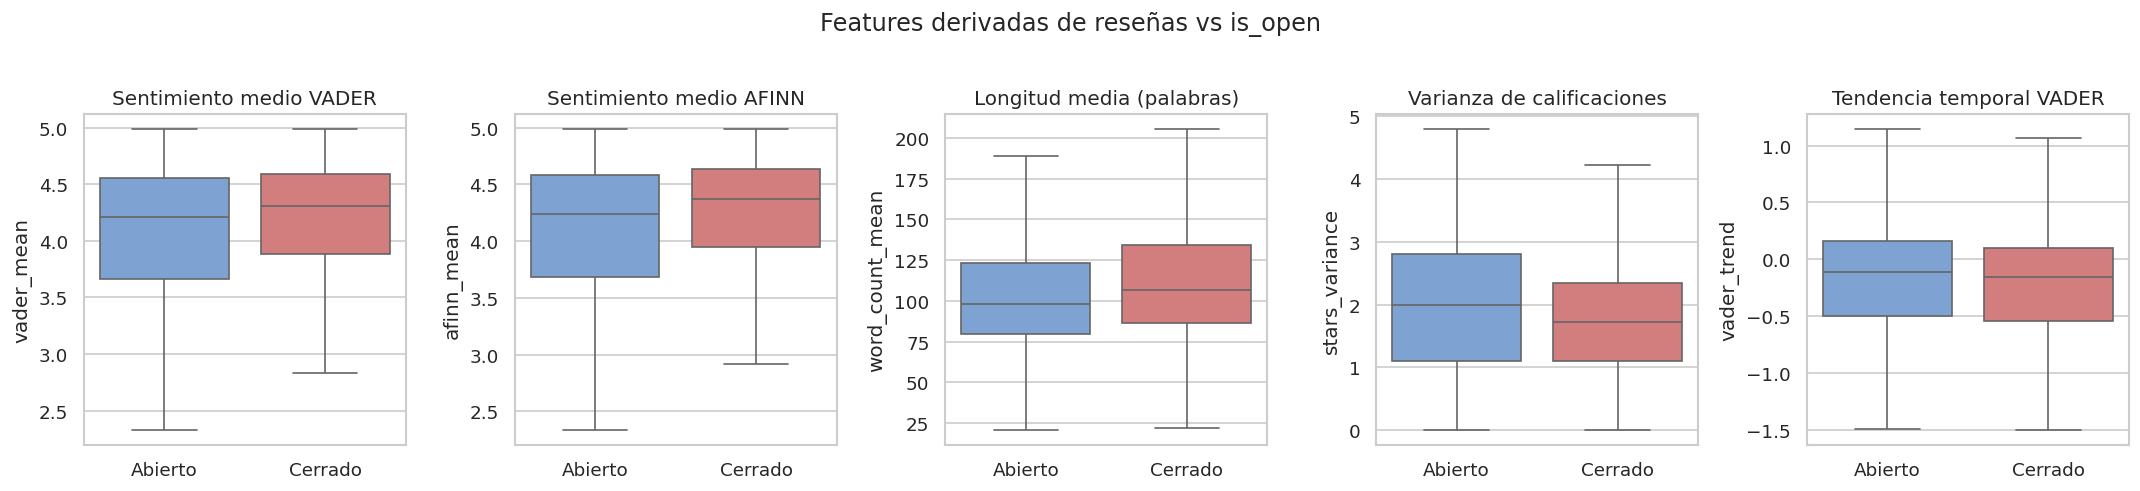

In [ ]:
features_resenas = {
    'vader_mean':       'Sentimiento medio VADER',
    'afinn_mean':       'Sentimiento medio AFINN',
    'word_count_mean':  'Longitud media (palabras)',
    'stars_variance':   'Varianza de calificaciones',
    'vader_trend':      'Tendencia temporal VADER',
}

fig, axes = plt.subplots(1, len(features_resenas), figsize=(18, 4))

for ax, (col, title) in zip(axes, features_resenas.items()):
    sns.boxplot(
        data=df_pd,
        x='is_open_label',
        y=col,
        ax=ax,
        palette={'Abierto': '#70a0e0', 'Cerrado': '#e07070'},
        showfliers=False
    )
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Features derivadas de reseñas vs is_open', y=1.02)
plt.tight_layout()
plt.show()

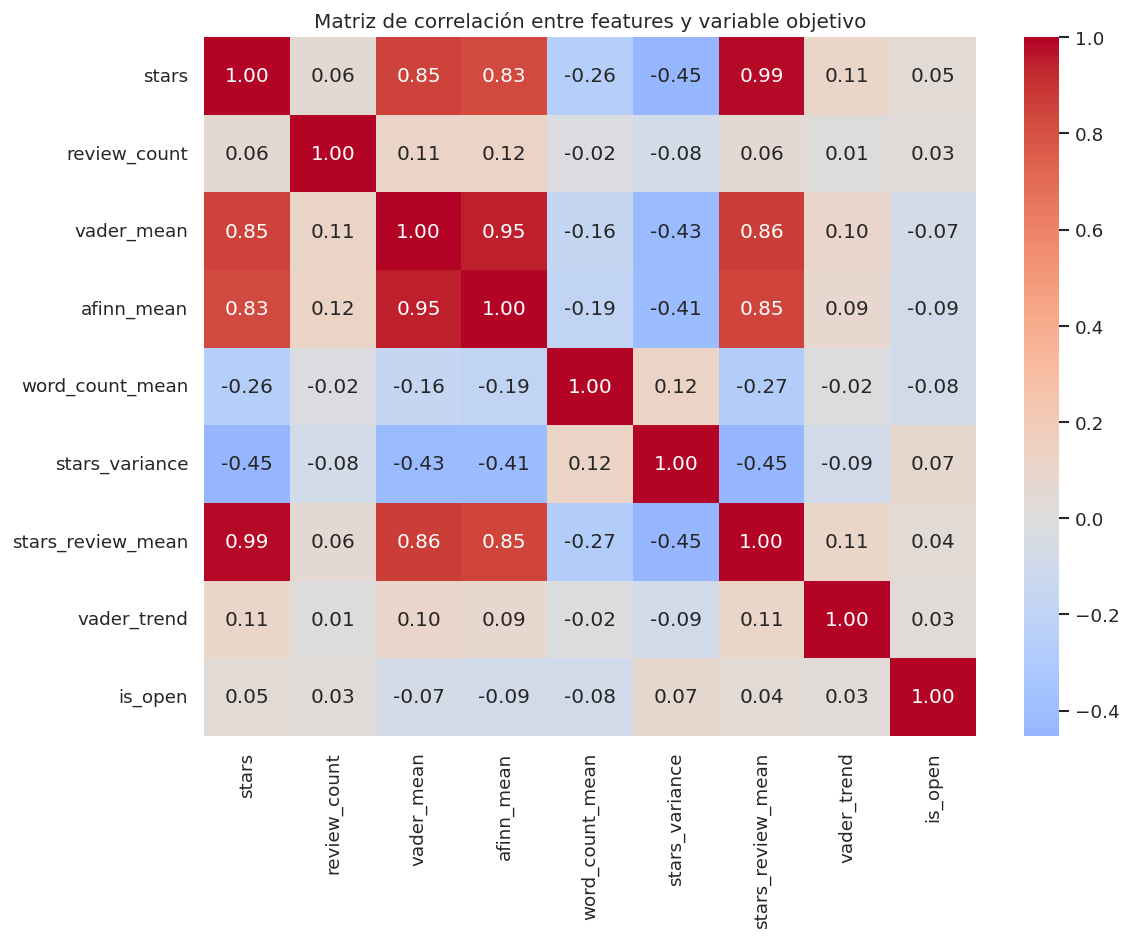


Correlación con is_open (ordenada):
stars_variance       0.072271
stars                0.045529
stars_review_mean    0.044177
review_count         0.029729
vader_trend          0.029547
vader_mean          -0.071757
word_count_mean     -0.084268
afinn_mean          -0.086325
Name: is_open, dtype: float64


In [ ]:
numeric_cols = [
    'stars', 'review_count',
    'vader_mean', 'afinn_mean',
    'word_count_mean', 'stars_variance',
    'stars_review_mean', 'vader_trend',
    'is_open'
]

corr_matrix = df_pd[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Matriz de correlación entre features y variable objetivo')
plt.tight_layout()
plt.show()

# Mostrar correlaciones con is_open ordenadas
print('\nCorrelación con is_open (ordenada):')
print(corr_matrix['is_open'].drop('is_open').sort_values(ascending=False))

In [ ]:
todas_cats = (
    df_model['categories']
    .drop_nulls()
    .str.split(', ')
    .explode()
    .to_list()
)

conteo_cats = Counter(todas_cats)
print(f'Categorías únicas reales: {len(conteo_cats):,}')
print('\nTop 30 categorías más frecuentes:')
for cat, count in conteo_cats.most_common(30):
    print(f'  {cat:<35} {count:>8,}')

In [ ]:
print('Número de valores únicos por variable categórica:')
print(f'  city:       {df_model["city"].n_unique():,}')
print(f'  state:      {df_model["state"].n_unique():,}')
print(f'  categories: {df_model["categories"].n_unique():,}')

# Top 20 ciudades por número de negocios
print('\nTop 20 ciudades por número de negocios:')
print(
    df_model
    .group_by('city')
    .len()
    .sort('len', descending=True)
    .head(20)
)

In [ ]:
df_model = (
    df_agg
    .join(df_business, on='business_id', how='inner')
    .drop(['vader_trend', 'stars_review_mean', 'review_count_scores'])
    .collect()
)

df_pd = df_model.to_pandas()

# One-hot encoding de state ---
state_dummies = pd.get_dummies(df_pd['state'], prefix='state')

# Multi-label binarization de categories (top 30) ---
todas_cats = (
    df_model['categories']
    .drop_nulls()
    .str.split(', ')
    .explode()
    .to_list()
)
conteo_cats = Counter(todas_cats)
top_cats = [cat for cat, _ in conteo_cats.most_common(30)]

cats_lists = (
    df_model['categories']
    .fill_null('')
    .str.split(', ')
    .to_list()
)

mlb = MultiLabelBinarizer(classes=top_cats)
cat_matrix = mlb.fit_transform(cats_lists)
cat_col_names = [
    f'cat_{c.replace(" ", "_").replace("&", "and").replace("(", "").replace(")", "")}'
    for c in top_cats
]
df_cats = pd.DataFrame(cat_matrix, columns=cat_col_names)

df_final = pd.concat([
    df_pd[[
        'business_id',
        'is_open',
        'stars',
        'review_count',
        'vader_mean',
        'afinn_mean',
        'word_count_mean',
        'stars_variance',
    ]],
    state_dummies,
    df_cats,
], axis=1)

df_final = df_final.dropna(subset=[
    'stars', 'review_count', 'vader_mean',
    'afinn_mean', 'word_count_mean', 'stars_variance'
])

print(f'Shape del dataset final: {df_final.shape}')
print(f'Columnas: {df_final.columns.tolist()}')
print(f'\nNulos restantes:\n{df_final.isnull().sum()[df_final.isnull().sum() > 0]}')
print(f'\nDistribución de is_open:\n{df_final["is_open"].value_counts()}')

os.makedirs('../data/csv', exist_ok=True)
output_path = '../data/csv/business_features.csv'
df_final.to_csv(output_path, index=False)
print(f'\nDataset guardado en: {output_path}')

/home/javclamar/Projects/tfg-sentiment-analysis/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['& Probates', '3D Printing', 'ATV Rentals/Tours', 'Acai Bowls', 'Accessories', 'Accountants', 'Acne Treatment', 'Acupuncture', 'Addiction Medicine', 'Adoption Services', 'Adult', 'Adult Education', 'Adult Entertainment', 'Advertising', 'Aerial Fitness', 'Aerial Tours', 'Aestheticians', 'Afghan', 'African', 'Air Duct Cleaning', 'Aircraft Dealers', 'Aircraft Repairs', 'Airlines', 'Airport Lounges', 'Airport Shuttles', 'Airport Terminals', 'Airports', 'Airsoft', 'Allergists', 'Alternative Medicine', 'Amateur Sports Teams', 'Amusement Parks', 'Anesthesiologists', 'Animal Assisted Therapy', 'Animal Physical Therapy', 'Animal Shelters', 'Antiques', 'Apartment Agents', 'Apartments', 'Appliances', 'Appliances & Repair', 'Appraisal Services', 'Aquarium Services', 'Aquariums', 'Arabic', 'Arcades', 'Archery', 'Architects', 'Architectural Tours', '

Shape del dataset final: (150243, 65)
Columnas: ['business_id', 'is_open', 'stars', 'review_count', 'vader_mean', 'afinn_mean', 'word_count_mean', 'stars_variance', 'state_AB', 'state_AZ', 'state_CA', 'state_CO', 'state_DE', 'state_FL', 'state_HI', 'state_ID', 'state_IL', 'state_IN', 'state_LA', 'state_MA', 'state_MI', 'state_MO', 'state_MT', 'state_NC', 'state_NJ', 'state_NV', 'state_PA', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VI', 'state_VT', 'state_WA', 'state_XMS', 'cat_Restaurants', 'cat_Food', 'cat_Shopping', 'cat_Home_Services', 'cat_Beauty_and_Spas', 'cat_Nightlife', 'cat_Health_and_Medical', 'cat_Local_Services', 'cat_Bars', 'cat_Automotive', 'cat_Event_Planning_and_Services', 'cat_Sandwiches', 'cat_American_Traditional', 'cat_Active_Life', 'cat_Pizza', 'cat_Coffee_and_Tea', 'cat_Fast_Food', 'cat_Breakfast_and_Brunch', 'cat_American_New', 'cat_Hotels_and_Travel', 'cat_Home_and_Garden', 'cat_Fashion', 'cat_Burgers', 'cat_Arts_and_Entertainment', 'cat_Auto_Repair